## Project 1:Fashion Dataset Sorting(Classification)

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy  as np
import matplotlib.pyplot as plt
import pydot
import sys

In [2]:
fashion_mnist =keras.datasets.fashion_mnist
(X_train_full ,y_train_full),(X_test ,y_test) =fashion_mnist.load_data()

In [3]:
X_train_full.shape

(60000, 28, 28)

In [4]:
X_train_full.dtype   

dtype('uint8')

In [5]:
X_valid , X_train =X_train_full[:5000] / 255. , X_train_full[5000:] /255.
y_valid , y_train =y_train_full[:5000] , y_train_full[5000:]
X_test =X_test /255

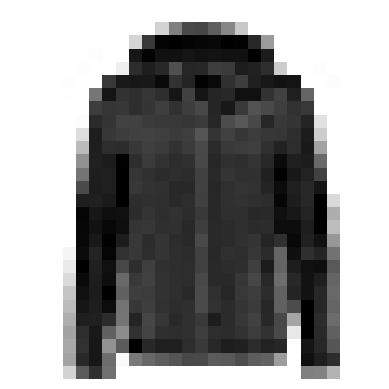

In [6]:
plt.imshow(X_train[0],cmap ="binary")
plt.axis('off')
plt.show()

In [7]:
y_train

array([4, 0, 7, ..., 3, 0, 5], shape=(55000,), dtype=uint8)

In [8]:
len(y_train)

55000

In [9]:
y_train[0]

np.uint8(4)

In [10]:
class_names = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

In [11]:
class_names[y_train[0]]

'Coat'

The validation set contains 5000 images and the test set contains 10,000 images.

In [12]:
X_valid.shape

(5000, 28, 28)

In [13]:
X_test.shape

(10000, 28, 28)

Let's take a look at a sample of the images in the dataset:

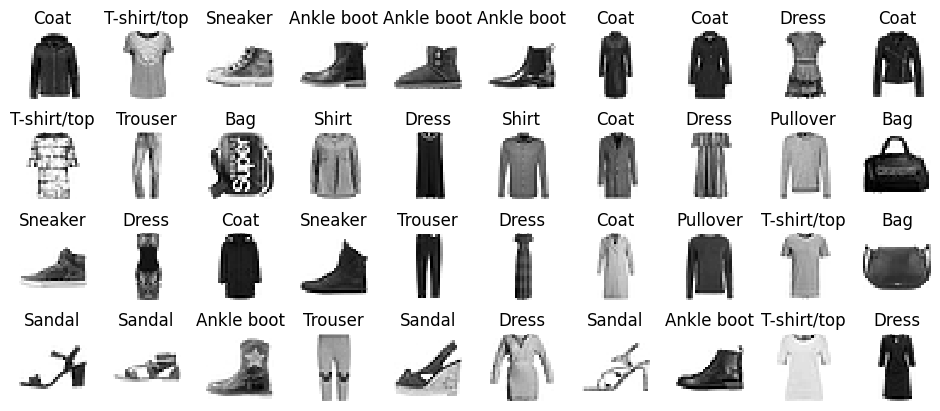

In [30]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2 ,n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index =n_cols * row+col
        plt.subplot(n_rows ,n_cols ,index +1)
        plt.imshow(X_train[index] ,cmap ="binary",interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]],fontsize=12)
plt.subplots_adjust(wspace =0.1 ,hspace =0.5) 
plt.show()

In [15]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(300 ,activation="relu"))
model.add(keras.layers.Dense(100 ,activation="relu"))
model.add(keras.layers.Dense(10,activation="softmax"))


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [17]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [18]:
model =keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(300,activation="relu"),
    keras.layers.Dense(100,activation="relu"),
    keras.layers.Dense(10,activation="softmax")
])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

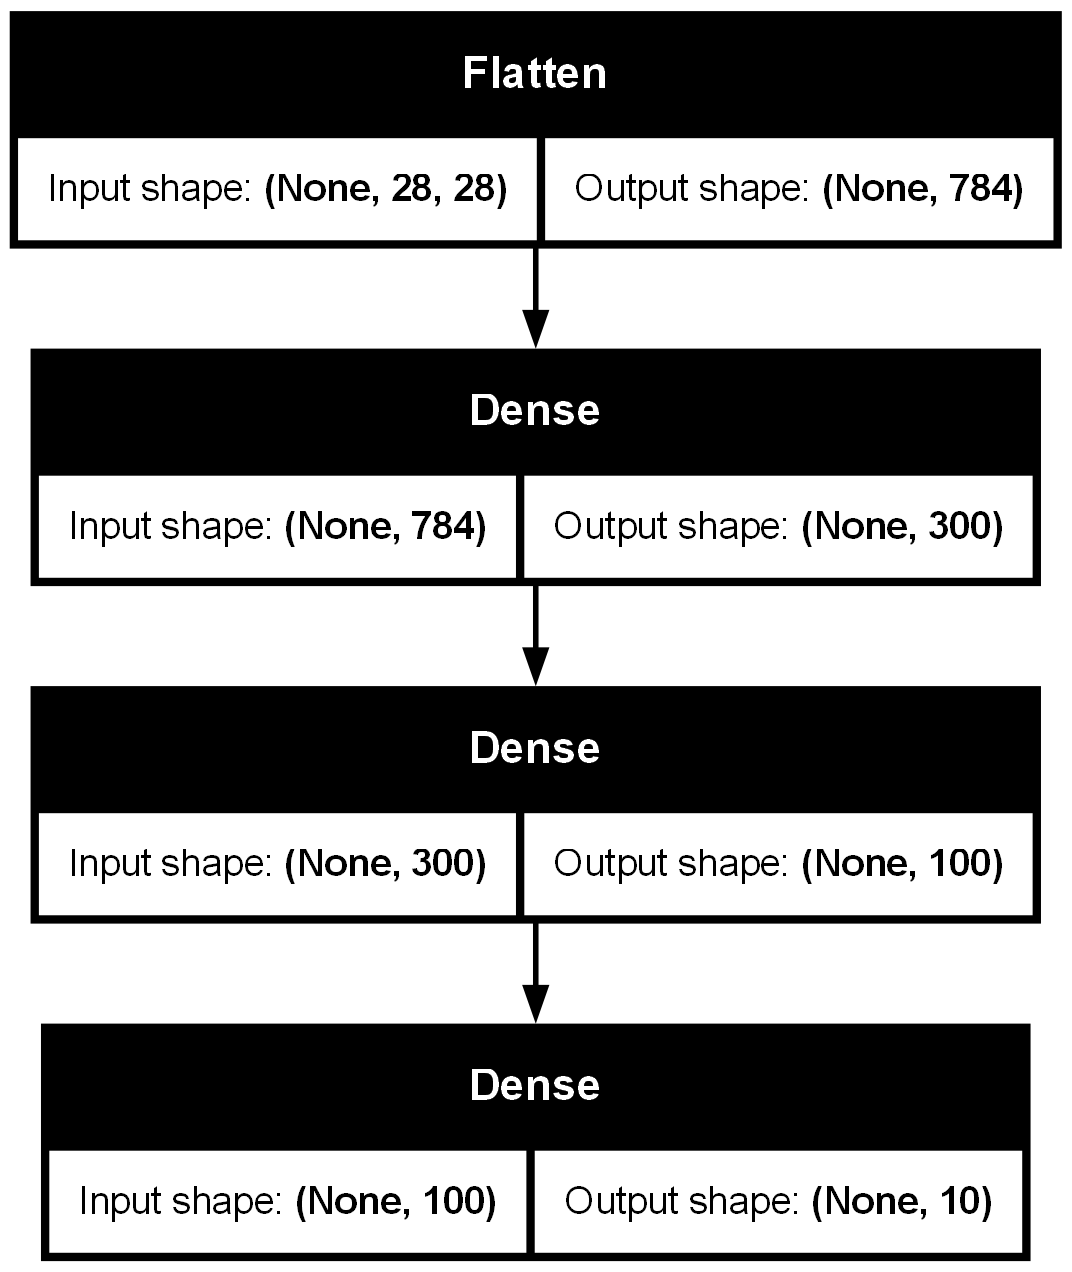

In [20]:
keras.utils.plot_model(model,"my_fashion_mnist_model.png",show_shapes=True)

In [21]:
hidden1 =model.layers[1]
hidden1.name

'dense'

In [22]:
model.get_layer(hidden1.name) is hidden1

True

In [23]:
weights , biases = hidden1.get_weights()

In [24]:
weights

array([[ 0.00559793, -0.04193761, -0.04971229, ..., -0.03303762,
        -0.03462582,  0.01531626],
       [-0.03193869, -0.05909183, -0.06252668, ...,  0.02912585,
         0.06316507, -0.03296257],
       [ 0.01784703,  0.02329821,  0.02037838, ...,  0.04208694,
        -0.04727399, -0.00065639],
       ...,
       [-0.00458635,  0.01722296, -0.04496473, ..., -0.04770149,
        -0.03191774, -0.05523552],
       [-0.05434664, -0.01998267,  0.05322589, ...,  0.05828263,
        -0.01662278, -0.04532752],
       [ 0.03431856, -0.06829578,  0.04902225, ...,  0.00020074,
        -0.07063434, -0.00436275]], shape=(784, 300), dtype=float32)

In [25]:
weights.shape

(784, 300)

In [31]:
biases.shape

(300,)

In [32]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [33]:
model.compile(loss="sparse_categorical_crossentropy",
             optimizer="sgd",
             metrics=["accuracy"])

In [56]:
model.compile
       (loss=keras.losses.sparse_categorical_crossentropy,
        optimizer=keras.optimizers.SGD(),
        metrics =[keras.metrics.sparse_categorical_accuracy])

IndentationError: unexpected indent (2218718716.py, line 2)

In [36]:
history =model.fit(X_train,y_train,epochs = 30,validation_data =(X_valid ,y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7630 - loss: 0.7189 - val_accuracy: 0.8238 - val_loss: 0.5190
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8304 - loss: 0.4861 - val_accuracy: 0.8464 - val_loss: 0.4548
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8454 - loss: 0.4407 - val_accuracy: 0.8540 - val_loss: 0.4204
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8548 - loss: 0.4136 - val_accuracy: 0.8604 - val_loss: 0.3981
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8617 - loss: 0.3939 - val_accuracy: 0.8682 - val_loss: 0.3824
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8671 - loss: 0.3783 - val_accuracy: 0.8700 - val_loss: 0.3705
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8709 - loss: 0.3651 - val_accuracy: 0.8732 - val_loss: 0.3604
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8747 - loss: 0.3536 - 

In [37]:
 history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [39]:
print(history.epoch)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


In [40]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

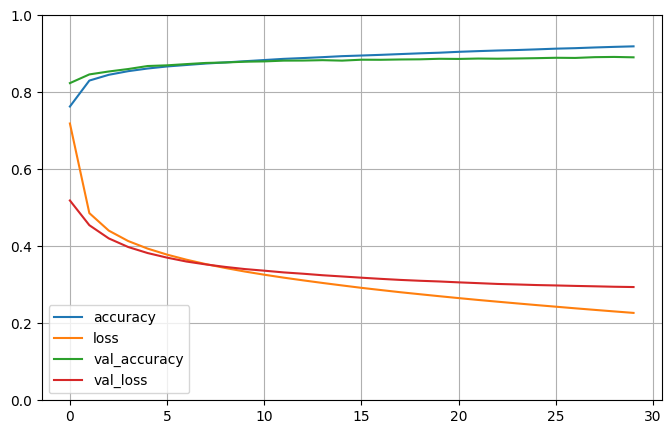

In [43]:
import pandas as pd
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

In [46]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8805 - loss: 0.3353


[0.33530116081237793, 0.8805000185966492]

## TESTING

In [47]:
X_new =X_test[:3]

This is how the test data look like 

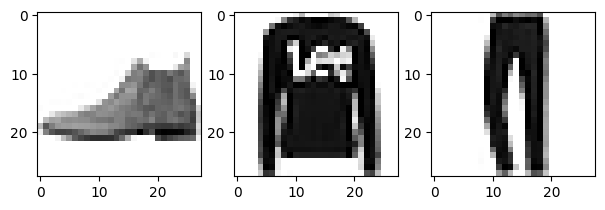

In [50]:
plt.figure(figsize=(7.2 ,2.4))
for index ,image in enumerate(X_new):
     plt.subplot(1,3,index+1)
     plt.imshow(image,cmap ="binary" ,interpolation="nearest")
plt.subplots_adjust(wspace = 0.2 ,hspace =0.5)
plt.show()

Let's see what our network predicts

In [51]:
# y_pred =model.predict_classes(X_new)
y_pred =np.argmax(model.predict(X_new),axis=-1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


array([9, 2, 1])

In [52]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

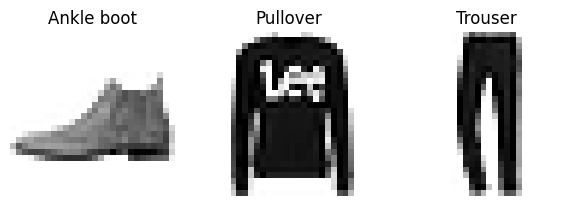

In [55]:
plt.figure(figsize=(7.2,2.4))
for index ,image in enumerate(X_new):
    plt.subplot(1,3,index+1)
    plt.imshow(image,cmap="binary",interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]],fontsize=12)
plt.subplots_adjust(wspace=0.2 ,hspace=0.5)
plt.show()